runs found: ['run-01', 'run-05']
searchlight samples: 10  (animate=4, inanimate=6, runs=2)
background image used: mean functional (no T1w anat found)


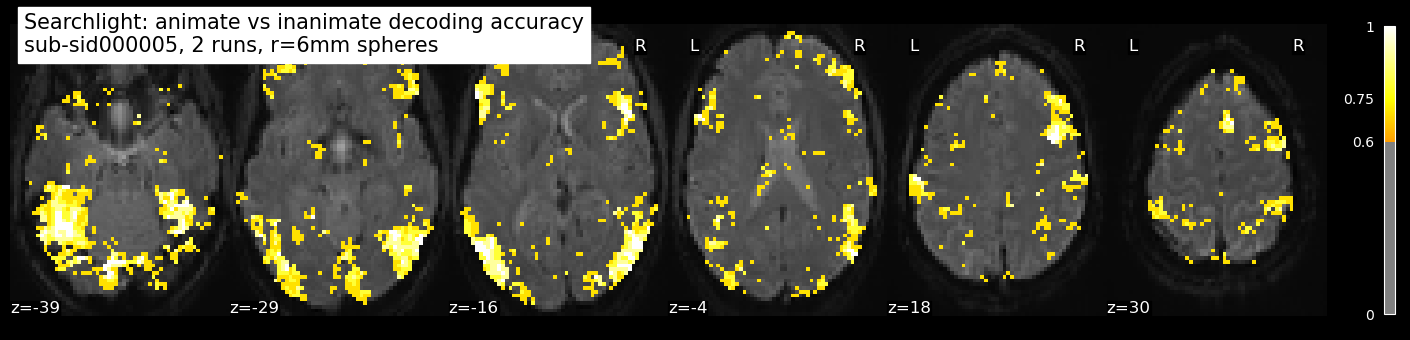

In [1]:
import glob
import numpy as np
import pandas as pd
from nilearn.glm.first_level import FirstLevelModel
from nilearn.image import concat_imgs, new_img_like, mean_img
from nilearn.decoding import SearchLight
from nilearn.plotting import plot_stat_map, show
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut

categories = ["faces", "bodies", "objects", "scenes", "scrambled_objects"]
animate_label = {"faces": 1, "bodies": 1, "objects": 0, "scenes": 0, "scrambled_objects": 0}
motion = ["trans_x", "trans_y", "trans_z", "rot_x", "rot_y", "rot_z"]
sub = "sub-sid000005"
DERIV = "/home/jovyan/hyperface/ds007384"
RAW   = "/home/jovyan/hyperface/ds007329"

def prep(sub, run):
    d = f"{DERIV}/{sub}/ses-1/func"; r = f"{RAW}/{sub}/ses-1/func"
    base = f"{sub}_ses-1_task-localizer_{run}"
    bold = f"{d}/{base}_space-T1w_desc-preproc_bold.nii.gz"
    mask = f"{d}/{base}_space-T1w_desc-brain_mask.nii.gz"
    ev = pd.read_csv(f"{r}/{base}_events.tsv", sep="	")
    ev = ev[ev["stim_type"].isin(categories)][["onset", "duration", "stim_type"]].rename(
        columns={"stim_type": "trial_type"})
    conf = pd.read_csv(f"{d}/{base}_desc-confounds_timeseries.tsv", sep="	")[motion].fillna(0)
    return bold, mask, ev, conf


run_files = sorted(glob.glob(f"{RAW}/{sub}/ses-1/func/{sub}_ses-1_task-localizer_run-*_events.tsv"))
runs = [f.split("task-localizer_")[1].split("_events")[0] for f in run_files]
print("runs found:", runs)

#one beta map per category per run
beta_imgs, y, groups, mask_img, bg_bold = [], [], [], None, None
for run_i, run in enumerate(runs):
    bold, mask, ev, conf = prep(sub, run)
    if mask_img is None:
        mask_img = mask   # use run-01's brain mask to define the searchlight space
        bg_bold = bold    # same run's functional, for a background that's actually in this space
    glm = FirstLevelModel(t_r=1.0, mask_img=mask, high_pass=1/128, smoothing_fwhm=5).fit(
        bold, events=ev, confounds=conf)
    for cat in categories:
        beta_imgs.append(glm.compute_contrast(cat, output_type="effect_size"))
        y.append(animate_label[cat])
        groups.append(run_i)

y, groups = np.array(y), np.array(groups)
X_img = concat_imgs(beta_imgs)
print(f"searchlight samples: {X_img.shape[-1]}  "
      f"(animate={y.sum()}, inanimate={(y == 0).sum()}, runs={len(runs)})")

# searchlight: animate vs inanimate decoding accuracy, 6mm spheres
clf = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0))
searchlight = SearchLight(
    mask_img=mask_img, radius=6.0, estimator=clf,
    cv=LeaveOneGroupOut(), n_jobs=-1, verbose=0,
)
searchlight.fit(X_img, y, groups=groups)

scores_img = new_img_like(mask_img, searchlight.scores_)

# plot map defaults to an MNI152 template
anat_candidates = sorted(
    glob.glob(f"{DERIV}/{sub}/anat/{sub}*_desc-preproc_T1w.nii.gz")
    + glob.glob(f"{DERIV}/{sub}/ses-1/anat/{sub}*_desc-preproc_T1w.nii.gz")
)
bg_img = anat_candidates[0] if anat_candidates else mean_img(bg_bold)
print("background image used:", bg_img if isinstance(bg_img, str) else "mean functional (no T1w anat found)")

# animate vs inanimate above chance (0.5)
plot_stat_map(scores_img, bg_img=bg_img, threshold=0.6, vmax=1.0, cmap="hot",
              title=f"Searchlight: animate vs inanimate decoding accuracy\n"
                    f"{sub}, {len(runs)} runs, r=6mm spheres",
              display_mode="z", cut_coords=6, colorbar=True)
show()

In [3]:
import numpy as np
import nibabel as nib
from nilearn.image import get_data

mask_data = get_data(mask_img) > 0
scores_data = get_data(scores_img)
in_mask = scores_data[mask_data]
n_vox = int(mask_data.sum())

print(f"voxels in brain mask: {n_vox}")
print(f"decoding accuracy within mask: mean={in_mask.mean():.3f}, "
      f"median={np.median(in_mask):.3f}, max={in_mask.max():.3f}")
print("(chance level for this 2-class animate vs inanimate problem = 0.500)\n")

for thr in [0.6, 0.7, 0.8]:
    n = int((in_mask > thr).sum())
    print(f"voxels with accuracy > {thr}: {n}  ({100*n/n_vox:.2f}% of the mask)")

#  best-decoding voxels
affine = scores_img.affine
masked_scores = np.where(mask_data, scores_data, -np.inf)
flat = masked_scores.ravel()
top_idx = np.argsort(flat)[::-1][:10]
coords_vox = np.array(np.unravel_index(top_idx, masked_scores.shape)).T
coords_mm = nib.affines.apply_affine(affine, coords_vox)

print("\nTop 10 voxels by decoding accuracy (native T1w-space mm coordinates):")
for (x, y_mm, z), score in zip(coords_mm, flat[top_idx]):
    print(f"  ({x:6.1f}, {y_mm:6.1f}, {z:6.1f}) mm : accuracy = {score:.3f}")

print(
    "- Each value is the cross-validated (leave-one-run-out) accuracy of a linear SVM\n"
    "  decoding animate vs inanimate from a 6mm sphere centered on that voxel.\n")

voxels in brain mask: 105906
decoding accuracy within mask: mean=0.478, median=0.500, max=1.000
(chance level for this 2-class animate vs inanimate problem = 0.500)

voxels with accuracy > 0.6: 19283  (18.21% of the mask)
voxels with accuracy > 0.7: 4966  (4.69% of the mask)
voxels with accuracy > 0.8: 2010  (1.90% of the mask)

Top 10 voxels by decoding accuracy (native T1w-space mm coordinates):
  ( -42.8,  -41.7,  -19.1) mm : accuracy = 1.000
  ( -42.8,  -41.7,  -21.6) mm : accuracy = 1.000
  (  44.7,  -29.2,  -36.6) mm : accuracy = 1.000
  (  44.7,  -29.2,  -41.6) mm : accuracy = 1.000
  (  44.7,  -29.2,  -39.1) mm : accuracy = 1.000
  ( -27.8,  -19.2,  -39.1) mm : accuracy = 1.000
  (  37.2,   28.3,   25.9) mm : accuracy = 1.000
  ( -42.8,  -39.2,  -16.6) mm : accuracy = 1.000
  ( -42.8,  -39.2,  -19.1) mm : accuracy = 1.000
  ( -40.3,  -24.2,  -44.1) mm : accuracy = 1.000
- Each value is the cross-validated (leave-one-run-out) accuracy of a linear SVM
  decoding animate vs inanim